In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC, OneClassSVM
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.ensemble import StackingClassifier
from sklearn.decomposition import PCA


In [2]:
df = pd.read_csv("C:\\Users\\sobha\\Downloads\\Phishing_Email.csv\\Phishing_Email.csv")
df.describe()

,Unnamed: 0
count,18650.000000
mean,9325.154477
std,5384.327293
min,0.000000
25%,4662.250000
50%,9325.500000
75%,13987.750000
max,18650.000000


In [3]:
df.head(10)

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email
5,5,global risk management operations sally congra...,Safe Email
6,6,"On Sun, Aug 11, 2002 at 11:17:47AM +0100, wint...",Safe Email
7,7,"entourage , stockmogul newsletter ralph velez ...",Phishing Email
8,8,"we owe you lots of money dear applicant , afte...",Phishing Email
9,9,re : coastal deal - with exxon participation u...,Safe Email


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  18650 non-null  int64 
 1   Email Text  18634 non-null  object
 2   Email Type  18650 non-null  object
dtypes: int64(1), object(2)
memory usage: 437.2+ KB


In [5]:
df.dropna(inplace=True)

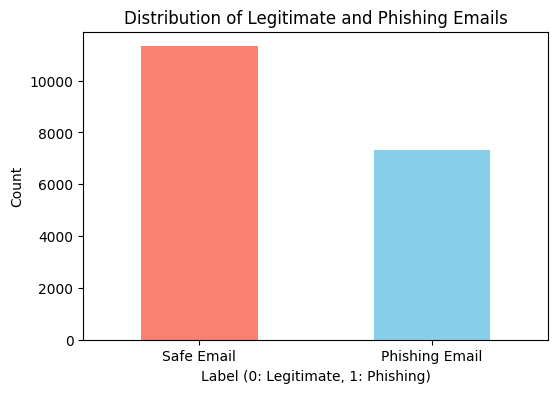

In [6]:
plt.figure(figsize=(6, 4))
df['Email Type'].value_counts().plot(kind='bar', color=['salmon', 'skyblue'])
plt.title('Distribution of Legitimate and Phishing Emails')
plt.xlabel('Label (0: Legitimate, 1: Phishing)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [7]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as stop_words

def clean_text(text):
    text = re.sub(r'\W', ' ', text)  
    text = text.lower()  
    text = text.split()  
    text = [word for word in text if word not in stop_words]  
    return ' '.join(text)

In [8]:
x= df['Email Text'].apply(clean_text).tolist()
y = df['Email Type']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [9]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

c:\Users\sobha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


[LightGBM] [Info] Number of positive: 9113, number of negative: 5794
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.253810 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 319127
[LightGBM] [Info] Number of data points in the train set: 14907, number of used features: 4876
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.611324 -> initscore=0.452879
[LightGBM] [Info] Start training from score 0.452879


IndexError: index 9 is out of bounds for axis 0 with size 9

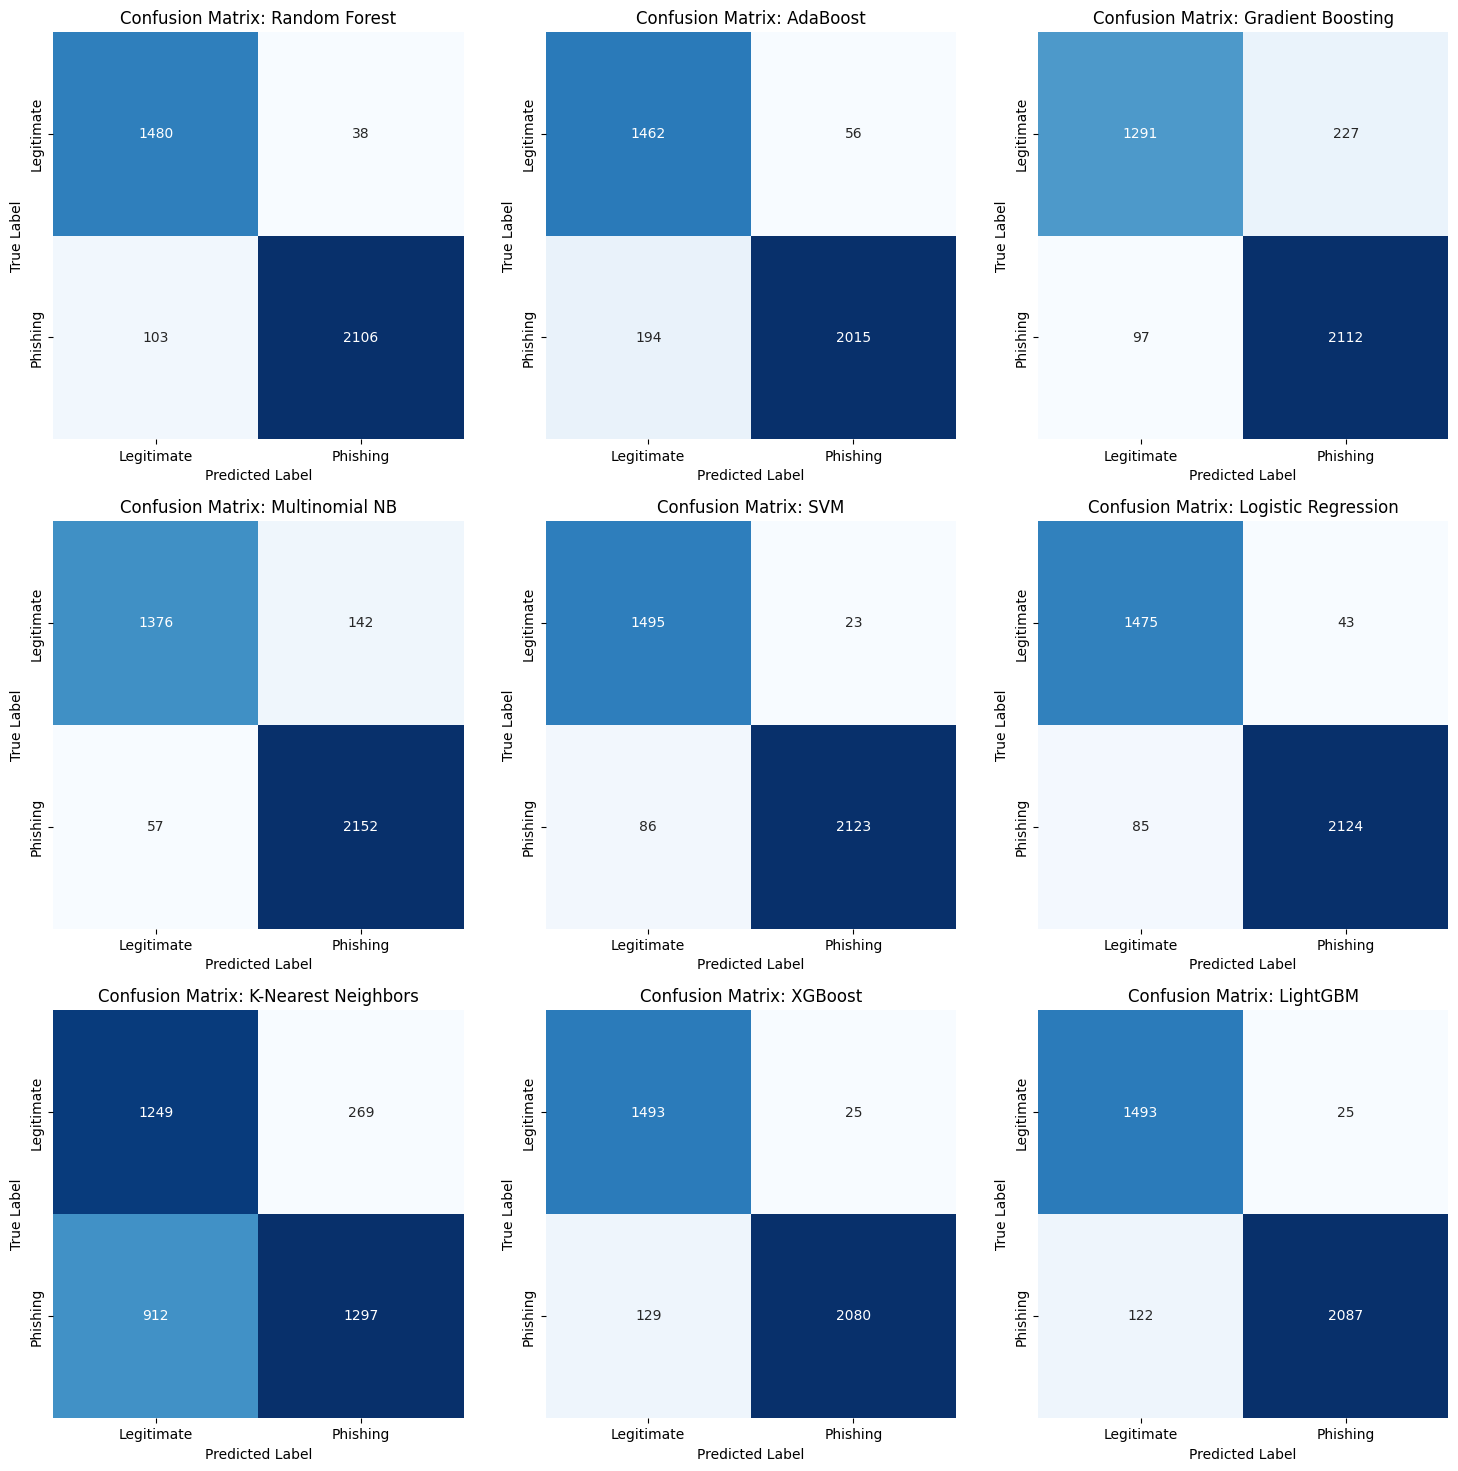

In [12]:
# Initialize the figure for all plots
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode the target labels into numeric values
y_train_encoded = label_encoder.fit_transform(y_train)  # This will convert 'Safe Email' -> 0, 'Phishing Email' -> 1
y_test_encoded = label_encoder.transform(y_test)  # Apply the same transformation to the test set

# Train and evaluate models
model_count = 0  # Counter to track the index for subplots
for model_name, model in models.items():
    if model_name in ['One-Class SVM', 'Isolation Forest']:
        model.fit(X_train_tfidf)
        y_pred = model.predict(X_test_tfidf)
        y_pred = np.where(y_pred == 1, 0, 1)  # Convert to binary (1 = phishing)
    else:
        # For KMeans, train the model and map clusters to labels
        if model_name == 'KMeans':
            model.fit(X_train_tfidf)
            kmeans_labels = model.predict(X_train_tfidf)
            
            # Map KMeans clusters to the actual labels (Phishing or Legitimate)
            cluster_0_label = np.bincount(y_train_encoded[kmeans_labels == 0]).argmax()  # Majority class in cluster 0
            cluster_1_label = np.bincount(y_train_encoded[kmeans_labels == 1]).argmax()  # Majority class in cluster 1
            
            # Map the clusters to labels
            kmeans_labels_mapped = np.where(kmeans_labels == 0, cluster_0_label, cluster_1_label)
            y_pred = model.predict(X_test_tfidf)
            
            # Map predicted clusters to labels
            kmeans_test_labels_mapped = np.where(y_pred == 0, cluster_0_label, cluster_1_label)
        else:
            model.fit(X_train_tfidf, y_train_encoded)
            y_pred = model.predict(X_test_tfidf)

    # Calculate metrics
    acc = accuracy_score(y_test_encoded, y_pred)
    prec = precision_score(y_test_encoded, y_pred)
    rec = recall_score(y_test_encoded, y_pred)
    f1 = f1_score(y_test_encoded, y_pred)

    # Store results
    model_scores['Model'].append(model_name)
    model_scores['Accuracy'].append(acc)
    model_scores['Precision'].append(prec)
    model_scores['Recall'].append(rec)
    model_scores['F1 Score'].append(f1)

    # Confusion matrix for each model
    conf_matrix = confusion_matrix(y_test_encoded, y_pred)
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Legitimate', 'Phishing'], yticklabels=['Legitimate', 'Phishing'],
                ax=axes[model_count])
    axes[model_count].set_title(f'Confusion Matrix: {model_name}')
    axes[model_count].set_xlabel('Predicted Label')
    axes[model_count].set_ylabel('True Label')

    # Increment the model count for the next plot
    model_count += 1


# KMeans clustering for comparison (unsupervised learning)
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_train_tfidf)

# Mapping cluster labels to 'Phishing Email' and 'Safe Email' based on majority class
# Count the majority class in each cluster
cluster_0_label = np.bincount(y_train_encoded[kmeans_labels == 0]).argmax()  # Majority class in cluster 0
cluster_1_label = np.bincount(y_train_encoded[kmeans_labels == 1]).argmax()  # Majority class in cluster 1

# Map cluster labels to 'Phishing Email' (1) and 'Safe Email' (0)
kmeans_labels_mapped = np.where(kmeans_labels == 0, cluster_0_label, cluster_1_label)

# For test data, predict the cluster and map it accordingly
kmeans_test_labels = kmeans.predict(X_test_tfidf)
kmeans_test_labels_mapped = np.where(kmeans_test_labels == 0, cluster_0_label, cluster_1_label)

# Calculate metrics for KMeans (Now mapped to 'Phishing Email' and 'Safe Email')
acc = accuracy_score(y_test_encoded, kmeans_test_labels_mapped)
prec = precision_score(y_test_encoded, kmeans_test_labels_mapped)
rec = recall_score(y_test_encoded, kmeans_test_labels_mapped)
f1 = f1_score(y_test_encoded, kmeans_test_labels_mapped)

# Store results for KMeans
model_scores['Model'].append('KMeans')
model_scores['Accuracy'].append(acc)
model_scores['Precision'].append(prec)
model_scores['Recall'].append(rec)
model_scores['F1 Score'].append(f1)

"""# Confusion matrix for KMeans
conf_matrix = confusion_matrix(y_test_encoded, kmeans_test_labels_mapped)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legitimate', 'Phishing'], yticklabels=['Legitimate', 'Phishing'],
            ax=axes[idx])
axes[idx].set_title(f'Confusion Matrix: KMeans')
axes[idx].set_xlabel('Predicted Label')
axes[idx].set_ylabel('True Label')"""

In [ ]:
# Plot KMeans clustering
fig_kmeans, ax_kmeans = plt.subplots(figsize=(8, 6))
ax_kmeans.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', marker='o', edgecolor='k', s=50, alpha=0.7)
ax_kmeans.set_title("K-Means Clustering of Emails (PCA-Reduced)")
ax_kmeans.set_xlabel("Principal Component 1")
ax_kmeans.set_ylabel("Principal Component 2")
fig_kmeans.colorbar(ax_kmeans.collections[0], label='Cluster Label')

# Visualize results in a comparison bar chart
df_scores = pd.DataFrame(model_scores)

# Bar chart for model performance comparison
fig_performance, ax_performance = plt.subplots(figsize=(12, 8))
bar_width = 0.2
r1 = np.arange(len(df_scores['Model']))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]
r4 = [x + bar_width for x in r3]

ax_performance.bar(r1, df_scores['Accuracy'], color='blue', width=bar_width, edgecolor='grey', label='Accuracy')
ax_performance.bar(r2, df_scores['Precision'], color='green', width=bar_width, edgecolor='grey', label='Precision')
ax_performance.bar(r3, df_scores['Recall'], color='orange', width=bar_width, edgecolor='grey', label='Recall')
ax_performance.bar(r4, df_scores['F1 Score'], color='red', width=bar_width, edgecolor='grey', label='F1 Score')

# Add scores above bars
for i in range(len(r1)):
    ax_performance.text(r1[i], df_scores['Accuracy'][i] + 0.01, f"{df_scores['Accuracy'][i]:.2f}", ha='center')
    ax_performance.text(r2[i], df_scores['Precision'][i] + 0.01, f"{df_scores['Precision'][i]:.2f}", ha='center')
    ax_performance.text(r3[i], df_scores['Recall'][i] + 0.01, f"{df_scores['Recall'][i]:.2f}", ha='center')
    ax_performance.text(r4[i], df_scores['F1 Score'][i] + 0.01, f"{df_scores['F1 Score'][i]:.2f}", ha='center')

# Chart aesthetics
ax_performance.set_xlabel('Models', fontweight='bold')
ax_performance.set_ylabel('Scores')
ax_performance.set_title('Model Comparison: Accuracy, Precision, Recall, and F1 Score')
ax_performance.set_xticks([r + bar_width for r in range(len(df_scores['Model']))])
ax_performance.set_xticklabels(df_scores['Model'], rotation=45, ha="right")
ax_performance.legend(loc="center", bbox_to_anchor=(0.5, -0.2), ncol=4)

plt.tight_layout()
plt.show()